In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.stats import fisher_exact
from matplotlib_venn import venn2
from matplotlib_venn import venn3

# Finding the HGNC IDs

### Gene symbol correction and HGNC annotation pipeline

This cell corrects gene symbols that were inadvertently converted to dates by Excel (e.g. `Mar-01` → `MARCH1`) in CRISPR screen files (obtained from tables or supplementary files of the related manuscripts), constructs a comprehensive HGNC-based lookup table using primary symbols, previous symbols, and aliases, and batch-processes all `*_screen.xlsx` files. For each gene, the pipeline first attempts annotation using the corrected symbol and falls back to the original symbol if needed, before exporting the annotated results with HGNC, Ensembl, and Entrez identifiers as CSV files.


In [ ]:
import os
import glob
import numpy as np
import pandas as pd

# ------------------------------
# 1) Fix Excel-mangled symbols
# ------------------------------
def fix_excel_gene_names(df, col="Gene"):
    corrected = []
    for g in df[col].astype(str):
        g_strip = g.strip()

        # MARCH: Mar-XX  -> MARCH<XX> (int() removes leading zeros)
        if g_strip.startswith(("Mar-", "MAR-")):
            num = g_strip.split("-")[1]
            corrected.append(f"MARCH{int(num)}")
            continue

        # SEPT: Sep-XX   -> SEPT<XX>
        if g_strip.startswith(("Sep-", "SEP-")):
            num = g_strip.split("-")[1]
            corrected.append(f"SEPT{int(num)}")
            continue

        # OCT: Oct-XX    -> OCT<XX>
        if g_strip.startswith(("Oct-", "OCT-")):
            num = g_strip.split("-")[1]
            corrected.append(f"OCT{int(num)}")
            continue

        # DEC: Dec-XX    -> DEC<XX>
        if g_strip.startswith(("Dec-", "DEC-")):
            num = g_strip.split("-")[1]
            corrected.append(f"DEC{int(num)}")
            continue

        corrected.append(g_strip)

    df[col + "_corrected"] = corrected
    return df

# -----------------------------------
# 2) Build HGNC lookup (symbol → IDs)
# -----------------------------------
hgnc = pd.read_csv(
    'input_data/HGNC/hgnc_complete_set.txt',
    sep='\t'
)
columns_to_include = ['hgnc_id', 'symbol', 'prev_symbol', 'ensembl_gene_id', 'alias_symbol', 'entrez_id']
hgnc_dict = hgnc[columns_to_include].to_dict(orient='records')

gene_lookup = {}

def normalize_symbol(s):
    return s.strip().upper() if isinstance(s, str) else None

for entry in hgnc_dict:
    hgnc_id = entry.get('hgnc_id', np.nan)
    ensembl_id = entry.get('ensembl_gene_id', np.nan)
    entrez_id = str(entry.get('entrez_id', 'NA')) if pd.notnull(entry.get('entrez_id')) else 'NA'

    syms = []
    # primary
    s = normalize_symbol(entry.get('symbol'))
    if s: syms.append(s)
    # previous symbols
    if pd.notnull(entry.get('prev_symbol')):
        syms.extend(normalize_symbol(x) for x in entry['prev_symbol'].split('|'))
    # alias symbols
    if pd.notnull(entry.get('alias_symbol')):
        syms.extend(normalize_symbol(x) for x in entry['alias_symbol'].split('|'))

    for sym in syms:
        if sym and sym not in gene_lookup:
            gene_lookup[sym] = (hgnc_id, ensembl_id, entrez_id)

def lookup_gene_info(symbol):
    key = normalize_symbol(symbol)
    return gene_lookup.get(key, (np.nan, np.nan, 'NA'))

# -----------------------------------
# 3) Process all *_screen.xlsx files
# -----------------------------------
input_dir = "input_data/1_resistance_screens/"
file_list = glob.glob(os.path.join(input_dir, "*_screen.xlsx"))

output_dir = "input_data/2_output_with_hgnc/"
os.makedirs(output_dir, exist_ok=True)

for file in file_list:
    df = pd.read_excel(file)

    # fix Excel date-mangled symbols -> new column 'Gene_corrected'
    df = fix_excel_gene_names(df, col="Gene")

    # lookup with fallback: try corrected, then original if not found
    def _lookup_row(row):
        h, e, n = lookup_gene_info(row["Gene_corrected"])
        if pd.isna(h):  # fallback to original symbol
            h, e, n = lookup_gene_info(row["Gene"])
        return pd.Series([h, e, n], index=["hgnc_id", "ensembl_gene_id", "entrez_id"])

    df[["hgnc_id", "ensembl_gene_id", "entrez_id"]] = df.apply(_lookup_row, axis=1)

    # save CSV
    out_file = os.path.join(
        output_dir,
        os.path.basename(file).replace(".xlsx", "_with_hgnc.csv")
    )
    df.to_csv(out_file, index=False)
    print(f"Processed & saved: {out_file} → {df.shape[0]} rows")


/var/folders/cs/dzdz0ppx7lld40ztphtqg_dh0000gp/T/ipykernel_96788/3307976444.py:46: DtypeWarning: Columns (32,34,38,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc = pd.read_csv(


Processed & saved: input_data/2_output_with_hgnc/krall_NRAS_MEK_screen_with_hgnc.csv → 18899 rows
Processed & saved: input_data/2_output_with_hgnc/noordermeer_BRCA1_PARP1_screen_with_hgnc.csv → 17235 rows
Processed & saved: input_data/2_output_with_hgnc/hayes_NRAS_MEK_screen_with_hgnc.csv → 16137 rows
Processed & saved: input_data/2_output_with_hgnc/krall_KRAS_MEK_screen_with_hgnc.csv → 18899 rows
Processed & saved: input_data/2_output_with_hgnc/dunn_PTEN_PIK3CB_screen_with_hgnc.csv → 18010 rows
Processed & saved: input_data/2_output_with_hgnc/awwad_ARID1A_ATR_screen_with_hgnc.csv → 18984 rows
Processed & saved: input_data/2_output_with_hgnc/yu_KRAS_MEK_screen_with_hgnc.csv → 18137 rows
Processed & saved: input_data/2_output_with_hgnc/dunn_PTEN_AKT_screen_with_hgnc.csv → 18012 rows
Processed & saved: input_data/2_output_with_hgnc/wang_KRAS_MEK_screen_with_hgnc.csv → 19246 rows
Processed & saved: input_data/2_output_with_hgnc/zimmermann_BRCA1_PARP1_screen_with_hgnc.csv → 15463 rows
Proc

# Overlappling of aggregation screens and Venn

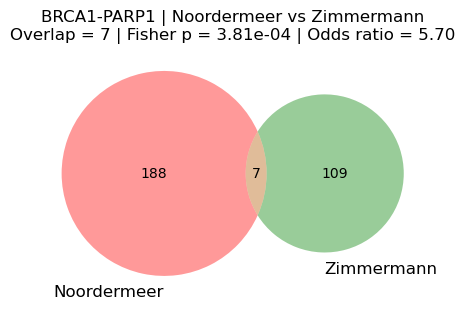

Noordermeer: 195 resistant hits | Zimmermann: 116 resistant hits | overlap: 7
Universe size (all tested genes union): N=17003
Fisher exact (greater): p=3.810e-04, -log10(p)=3.42, oddsratio=5.704


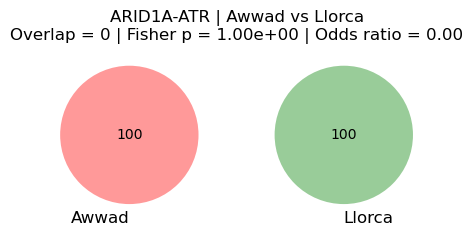

Awwad: 100 resistant hits | Llorca: 100 resistant hits | overlap: 0
Universe size (all tested genes union): N=18839
Fisher exact (greater): p=1.000e+00, -log10(p)=-0.00, oddsratio=0.000


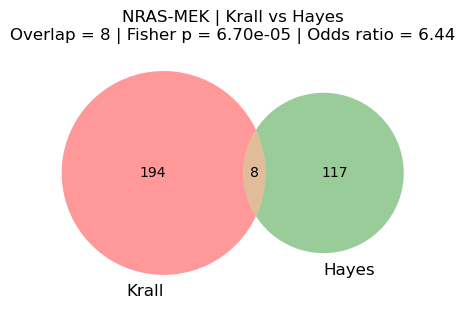

Krall: 202 resistant hits | Hayes: 125 resistant hits | overlap: 8
Universe size (all tested genes union): N=18598
Fisher exact (greater): p=6.696e-05, -log10(p)=4.17, oddsratio=6.443


In [5]:
# =====================
# CONFIG
# =====================
INPUT_DIR = "input_data/2_output_with_hgnc"
OUT_DIR   = "results/1_overlap_resistants"
HGNC_COL  = "hgnc_id"

# =====================
# Helpers
# =====================
def _clean(series):
    """Standardize HGNC ids: drop NA/empty, strip, cast to str."""
    series = series.dropna().astype(str).str.strip()
    return {x for x in series if x not in {"", "NA", "nan"}}

def load_resistant_and_all(csv_path, hgnc_col):
    df = pd.read_csv(csv_path)
    # all tested genes
    all_genes = _clean(df[hgnc_col])
    # resistant-only
    df_res = df[df["Resistance"].astype(str).str.lower() == "resistant"]
    resistant = _clean(df_res[hgnc_col])
    return resistant, all_genes

def venn_and_fisher_resistant(resA, resB, allA, allB, labelA, labelB, pairs, out_png=None):
    a = len(resA)
    b = len(resB)
    k = len(resA & resB)
    N = len(allA | allB)  # universe = union of all tested genes

    # Fisher’s exact test
    table = [[k, a - k],
             [b - k, N - a - b + k]]
    odds, pval = fisher_exact(table, alternative="greater")
    neglog10p = -np.log10(pval) if pval > 0 else np.inf

    # Plot venn diagram
    plt.figure(figsize=(5, 5))
    venn2([resA, resB], set_labels=(labelA, labelB))
    # Add overlap, Fisher p-value, and odds ratio to title
    pairs_pretty = pairs.replace("_", "-")
    plt.title(
        f"{pairs_pretty} | {labelA} vs {labelB}\n"
        f"Overlap = {k} | Fisher p = {pval:.2e} | Odds ratio = {odds:.2f}"
    )
    if out_png:
        os.makedirs(os.path.dirname(out_png), exist_ok=True)
        plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"{labelA}: {a} resistant hits | {labelB}: {b} resistant hits | overlap: {k}")
    print(f"Universe size (all tested genes union): N={N}")
    print(f"Fisher exact (greater): p={pval:.3e}, -log10(p)={neglog10p:.2f}, oddsratio={odds:.3f}")

# =====================
# Main wrapper function
# =====================
def analyze_pair(pair_name):
    # Find matching files
    pattern = os.path.join(INPUT_DIR, f"*{pair_name}*_with_hgnc.csv")
    pairs = pair_name
    files = glob.glob(pattern)
    if len(files) != 2:
        raise ValueError(f"Expected 2 files for {pair_name}, found {len(files)} → {files}")

    # Load resistant + all genes
    resA, allA = load_resistant_and_all(files[0], HGNC_COL)
    resB, allB = load_resistant_and_all(files[1], HGNC_COL)

    # Labels = first word of filename
    labelA = os.path.basename(files[0]).split("_")[0].capitalize()
    labelB = os.path.basename(files[1]).split("_")[0].capitalize()

    # Output file
    out_png = os.path.join(OUT_DIR, f"venn_{pair_name}_{labelA}_vs_{labelB}.png")

    venn_and_fisher_resistant(resA, resB, allA, allB, labelA, labelB, pairs,out_png)

analyze_pair("BRCA1_PARP1")
analyze_pair("ARID1A_ATR")
analyze_pair("NRAS_MEK")


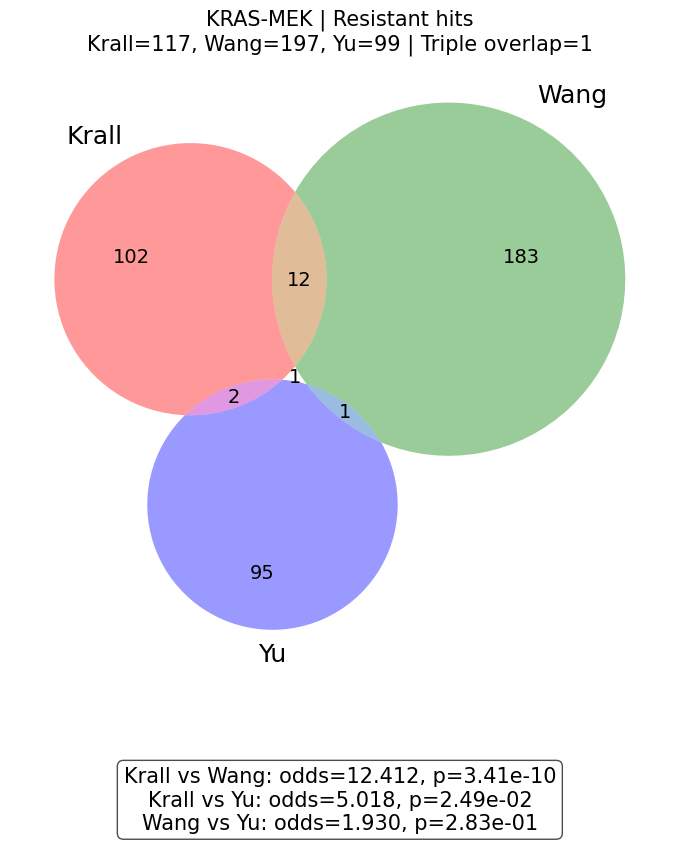

Saved Venn: results/1_overlap_resistants/venn3_KRAS_MEK_Krall_Wang_Yu.png
Saved pairwise Fisher summary: results/1_overlap_resistants/venn3_pairwise_fisher_KRAS_MEK.csv
Krall vs Wang: overlap=13, N=18572, odds ratio=12.412, p_val=3.41e-10
Krall vs Yu: overlap=3, N=18518, odds ratio=5.018, p_val=2.49e-02
Wang vs Yu: overlap=2, N=18551, odds ratio=1.930, p_val=2.83e-01


In [30]:
# =====================
# CONFIG
# =====================
INPUT_DIR = "input_data/2_output_with_hgnc"
OUT_DIR   = "results/1_overlap_resistants"
HGNC_COL  = "hgnc_id"
RESISTANCE_COL = "Resistance"

# =====================
# Helpers
# =====================
def _clean(series):
    """Return a clean set of HGNC IDs: strip, drop NA/empty/NA-like."""
    series = series.dropna().astype(str).str.strip()
    return {x for x in series if x not in {"", "NA", "nan"}}

def load_resistant_and_all(csv_path, hgnc_col=HGNC_COL, resistance_col=RESISTANCE_COL):
    df = pd.read_csv(csv_path)
    all_genes = _clean(df[hgnc_col])
    mask_res = df[resistance_col].astype(str).str.lower() == "resistant"
    resistant = _clean(df.loc[mask_res, hgnc_col])
    return resistant, all_genes

def short_label_from_filename(path):
    """First token before '_' (capitalized), e.g., 'noordermeer_...' -> 'Noordermeer'."""
    return os.path.basename(path).split("_")[0].capitalize()

def pairwise_fisher(set1, set2, all1, all2):
    """Fisher’s exact for enrichment of overlap between set1 and set2 with universe=all1 ∪ all2."""
    a = len(set1); b = len(set2); k = len(set1 & set2)
    N = len(all1 | all2)
    table = [[k, a - k],
             [b - k, N - a - b + k]]
    odds, pval = fisher_exact(table, alternative="greater")
    return {"a": a, "b": b, "k": k, "N": N, "oddsratio": odds, "pvalue": pval,
            "-log10_p": (-np.log10(pval) if pval > 0 else np.inf)}

# =====================
# Main function (3 screens)
# =====================
def analyze_triplet(pair_token):
    """
    Finds exactly 3 files matching *{pair_token}*_with_hgnc.csv,
    draws a 3-set Venn of Resistant hits, and runs pairwise Fishers (AB, AC, BC).
    """
    pattern = os.path.join(INPUT_DIR, f"*{pair_token}*_with_hgnc.csv")
    files = sorted(glob.glob(pattern))
    if len(files) != 3:
        raise ValueError(f"Expected 3 files for '{pair_token}', found {len(files)}:\n{files}")

    # Load sets
    (resA, allA) = load_resistant_and_all(files[0])
    (resB, allB) = load_resistant_and_all(files[1])
    (resC, allC) = load_resistant_and_all(files[2])

    labelA = short_label_from_filename(files[0])
    labelB = short_label_from_filename(files[1])
    labelC = short_label_from_filename(files[2])

    # --- Venn 3 (Resistant-only)
    os.makedirs(OUT_DIR, exist_ok=True)
    out_png = os.path.join(OUT_DIR, f"venn3_{pair_token}_{labelA}_{labelB}_{labelC}.png")

    plt.figure(figsize=(18, 8))
    v = venn3([resA, resB, resC], set_labels=(labelA, labelB, labelC))

    # increase font size of set labels (names)
    for label in v.set_labels:
        if label:  # check because sometimes a label can be None
            label.set_fontsize(18)

    # increase font size of subset labels (numbers in the diagram)
    for label in v.subset_labels:
        if label:  # some subsets may be empty → None
            label.set_fontsize(14)

    # annotate title with sizes and triple overlap
    kABC = len(resA & resB & resC)
    plt.title(
        f"{pair_token.replace('_','-')} | Resistant hits\n"
        f"{labelA}={len(resA)}, {labelB}={len(resB)}, {labelC}={len(resC)} | "
        f"Triple overlap={kABC}",fontsize = 15
    )

    # --- Pairwise Fishers
    res_ab = pairwise_fisher(resA, resB, allA, allB) | {"pair": "AB", "screen1": labelA, "screen2": labelB}
    res_ac = pairwise_fisher(resA, resC, allA, allC) | {"pair": "AC", "screen1": labelA, "screen2": labelC}
    res_bc = pairwise_fisher(resB, resC, allB, allC) | {"pair": "BC", "screen1": labelB, "screen2": labelC}

    # Format text block for annotation (no overlap or N)
    text_lines = [
        f"{res_ab['screen1']} vs {res_ab['screen2']}: odds={res_ab['oddsratio']:.3f}, p={res_ab['pvalue']:.2e}",
        f"{res_ac['screen1']} vs {res_ac['screen2']}: odds={res_ac['oddsratio']:.3f}, p={res_ac['pvalue']:.2e}",
        f"{res_bc['screen1']} vs {res_bc['screen2']}: odds={res_bc['oddsratio']:.3f}, p={res_bc['pvalue']:.2e}",
    ]
    annotation_text = "\n".join(text_lines)

    # Add annotation box to plot
    plt.text(
        0.5, -0.15, annotation_text,              # x=0.5 centers horizontally, y<0 moves below plot
        transform=plt.gca().transAxes,
        fontsize=15, va="top", ha="center",       # center align
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.7)
    )


    # Save and show
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved Venn: {out_png}")

    # --- Pairwise Fishers
    res_ab = pairwise_fisher(resA, resB, allA, allB) | {"pair": "AB", "screen1": labelA, "screen2": labelB}
    res_ac = pairwise_fisher(resA, resC, allA, allC) | {"pair": "AC", "screen1": labelA, "screen2": labelC}
    res_bc = pairwise_fisher(resB, resC, allB, allC) | {"pair": "BC", "screen1": labelB, "screen2": labelC}

    summary = pd.DataFrame([res_ab, res_ac, res_bc], columns=[
        "pair","screen1","screen2","a","b","k","N","oddsratio","pvalue","-log10_p"
    ])
    out_csv = os.path.join(OUT_DIR, f"venn3_pairwise_fisher_{pair_token}.csv")
    summary.to_csv(out_csv, index=False)
    print(f"Saved pairwise Fisher summary: {out_csv}")

    # Print a quick console summary
    for row in summary.to_dict("records"):
        print(f"{row['screen1']} vs {row['screen2']}: overlap={row['k']}, N={row['N']}, "
              f"odds ratio={row['oddsratio']:.3f}, p_val={row['pvalue']:.2e}")

analyze_triplet("KRAS_MEK")


# Aggregate the multiple pairs

In [6]:
# =====================
# CONFIG
# =====================
INPUT_DIR = "input_data/2_output_with_hgnc"   # folder with *_with_hgnc.csv files
OUT_DIR   = "input_data/2_output_with_hgnc"
PAIR_TOKEN_EXAMPLE = "KRAS_MEK"            # example token

# =====================
# Helpers
# =====================
VALID_NA = {"", "NA", "nan", "None", "NaN", "NAN"}

def _first_nonnull(series):
    for x in series:
        if pd.notna(x) and str(x).strip() not in VALID_NA:
            return x
    return np.nan

def _clean_hgnc(s):
    return pd.Series(s, dtype=str).str.strip()

def aggregate_screens(file_paths):
    """
    Aggregate 2 or 3 screen CSVs with columns:
    ['Resistance','Gene','Gene_corrected','hgnc_id','ensembl_gene_id','entrez_id'] (Cell_line can be present/ignored).
    Returns an aggregated DataFrame with the rule:
        any 'Resistant' across screens -> 'Resistant' in output; else 'Not_Resistant'.
    """
    if not (2 <= len(file_paths) <= 3):
        raise ValueError(f"Provide 2 or 3 files. Got {len(file_paths)} files:\n{file_paths}")

    frames = []
    for fp in file_paths:
        df = pd.read_csv(fp, dtype=str)
        # Ensure required columns exist
        for col in ["Resistance","Gene","hgnc_id","ensembl_gene_id","entrez_id"]:
            if col not in df.columns:
                df[col] = np.nan
        if "Gene_corrected" not in df.columns:
            df["Gene_corrected"] = df["Gene"]

        # Normalize types/strings
        df["hgnc_id"] = _clean_hgnc(df["hgnc_id"])
        df["Gene"] = df["Gene"].astype(str).str.strip()
        df["Gene_corrected"] = df["Gene_corrected"].astype(str).str.strip()
        df["ensembl_gene_id"] = df["ensembl_gene_id"].astype(str).str.strip()
        df["entrez_id"] = df["entrez_id"].astype(str).str.strip()

        # Boolean resistant per row
        is_res = df["Resistance"].astype(str).str.lower().eq("resistant")
        df = df.assign(is_resistant=is_res)

        # Keep only useful columns (drop Cell_line etc.)
        frames.append(df[["hgnc_id","Gene","Gene_corrected","ensembl_gene_id","entrez_id","is_resistant"]])

    # Stack & drop invalid HGNC IDs
    all_df = pd.concat(frames, ignore_index=True)
    valid_mask = all_df["hgnc_id"].notna() & (~all_df["hgnc_id"].isin(VALID_NA))
    all_df = all_df.loc[valid_mask].copy()

    # Aggregate by HGNC id
    agg = (all_df
           .groupby("hgnc_id", as_index=False)
           .agg({
               "is_resistant": "max",  # OR over screens
               "Gene": _first_nonnull,
               "Gene_corrected": _first_nonnull,
               "ensembl_gene_id": _first_nonnull,
               "entrez_id": _first_nonnull
           }))

    # Final Resistance label
    agg["Resistance"] = np.where(agg["is_resistant"], "Resistant", "Not_Resistant")
    agg = agg[["Resistance","Gene","Gene_corrected","hgnc_id","ensembl_gene_id","entrez_id"]]

    # Sort optional (Resistant first, then by symbol)
    agg = agg.sort_values(by=["Resistance","Gene_corrected"], ascending=[False, True], kind="stable").reset_index(drop=True)
    return agg

def aggregate_pair_token(pair_token, out_name=None):
    """
    Find 2–3 files matching *{pair_token}*_with_hgnc.csv in INPUT_DIR,
    aggregate them, and save CSV.
    """
    pattern = os.path.join(INPUT_DIR, f"*{pair_token}*_with_hgnc.csv")
    files = sorted(glob.glob(pattern))
    if not (2 <= len(files) <= 3):
        raise FileNotFoundError(f"Expected 2 or 3 files for '{pair_token}', found {len(files)}:\n{files}")

    agg = aggregate_screens(files)
    os.makedirs(OUT_DIR, exist_ok=True)
    if out_name is None:
        # Include short screen tags in filename
        tags = "_".join([os.path.basename(f).split("_")[0].capitalize() for f in files])
        out_name = f"{pair_token}_{tags}_aggregated.csv"
    out_path = os.path.join(OUT_DIR, out_name)
    agg.to_csv(out_path, index=False)
    print(f"Saved aggregated screen → {out_path}  (rows={len(agg)})")
    return agg


agg_df = aggregate_pair_token("BRCA1_PARP1")

# For 3 screens (if three files exist for the token):
# agg_df = aggregate_pair_token("KRAS_MEK")


Saved aggregated screen → input_data/2_output_with_hgnc/BRCA1_PARP1_Noordermeer_Zimmermann_aggregated.csv  (rows=17003)
